# CARMS — Phase 5 Paper Trading Exploration
Analyse simulation results, trade log, equity curve and regime-conditioned performance.

**Sections**
1. Setup & validation
2. Equity curve (portfolio value over time)
3. Regime-conditioned P&L
4. Trade log analysis
5. Meta-controller weight analysis
6. Risk metrics summary
7. Comparison vs buy-and-hold

In [1]:
import os, sys
from pathlib import Path
root = Path(os.getcwd())
for _ in range(5):
    if (root / 'main.py').exists(): break
    root = root.parent
os.chdir(root)
if str(root) not in sys.path: sys.path.insert(0, str(root))
print(f'Root: {root}')

Root: C:\Users\Mugithi\Documents\carms


In [2]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')
Path('logs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.3,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

from src.utils.logger import load_config
from src.live.phase5_runner import validate_phase5
from src.agents.backtester import _sharpe, _max_drawdown, _sortino

config = load_config('configs/config.yaml')
config['_base_dir'] = str(root)
for key in ['raw_dir','processed_dir','charts_dir']:
    config['data'][key] = str((root/config['data'][key]).resolve())
MODEL_DIR = str(root / 'models')

RCOLOURS = {
    'trending_up':'#1D9E75','trending_down':'#E24B4A',
    'ranging':'#B4B2A9','crisis':'#D85A30'
}
print('Ready')

Ready


## 1 — Validation

In [3]:
validate_phase5(config, MODEL_DIR)


────────────────────────────────────────────────────────────
  CARMS Phase 5 — Validation Report
────────────────────────────────────────────────────────────

  Paper Trade Simulation
    ✓ paper_trade_simulation.csv  (13 days)
       Return   : -7.5%
       Sharpe   : -4.92
       Max DD   : 10.6%

  Trade Log
    ✓ trade_log.csv  (55 trades logged)
       BTC-USD            12 trades
       ETH-USD            12 trades
       GC=F               12 trades
       EURUSD=X           10 trades
       KES=X               9 trades

  Portfolio State
    ✓ portfolio_state.json
       Value  : $9,252.09
       Trades : 55
       Halted : True

  Performance Assessment
    Sharpe > 1.0  : No
    Max DD < 15%  : Yes
    Status  : Negative Sharpe — review agents

────────────────────────────────────────────────────────────
  Checks passed: 3/4 (75%)
  Run: python main.py --phase 5
────────────────────────────────────────────────────────────



False

## 2 — Equity curve

In [4]:
sim_path = Path(MODEL_DIR) / 'paper_trade_simulation.csv'
sim_df   = pd.read_csv(sim_path) if sim_path.exists() else pd.DataFrame()

if not sim_df.empty:
    print(f'Simulation days : {len(sim_df)}')
    print(f'Final return    : {sim_df["total_return_%"].iloc[-1]:+.1f}%')
    print(f'Final Sharpe    : {sim_df["sharpe"].iloc[-1]:.2f}')
    print(f'Max drawdown    : {sim_df["max_drawdown_%"].iloc[-1]:.1f}%')
    print(f'Halted days     : {(sim_df["halted"]=="True").sum() if "halted" in sim_df.columns else 0}')
else:
    print('No simulation results — run: python main.py --phase 5')

Simulation days : 13
Final return    : -7.5%
Final Sharpe    : -4.92
Max drawdown    : 10.6%
Halted days     : 0


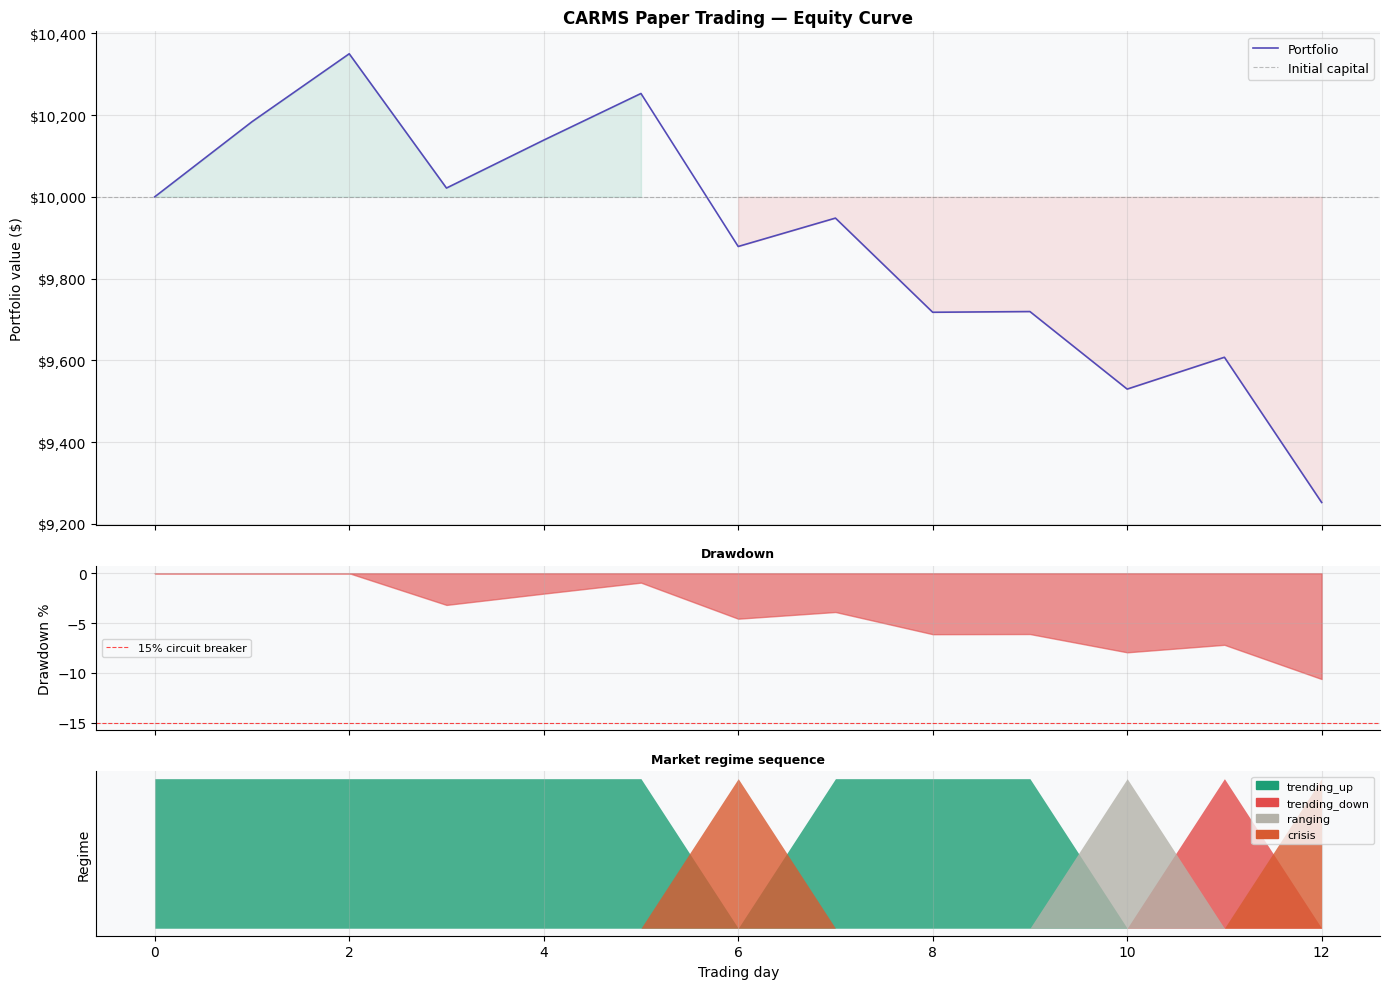

Saved → logs/p5_01_equity_curve.png


In [5]:
if not sim_df.empty and 'portfolio_value' in sim_df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                              gridspec_kw={'height_ratios':[3,1,1]}, sharex=True)

    x = range(len(sim_df))

    # Equity curve
    pv = sim_df['portfolio_value']
    axes[0].plot(x, pv, color='#534AB7', linewidth=1.2, label='Portfolio')
    axes[0].axhline(10000, color='gray', linestyle='--', linewidth=0.8,
                     alpha=0.5, label='Initial capital')
    axes[0].fill_between(x, 10000, pv,
                          where=(pv >= 10000), alpha=0.12, color='#1D9E75')
    axes[0].fill_between(x, 10000, pv,
                          where=(pv < 10000),  alpha=0.12, color='#E24B4A')
    axes[0].set_ylabel('Portfolio value ($)')
    axes[0].set_title('CARMS Paper Trading — Equity Curve', fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    # Drawdown
    peak = pv.cummax()
    dd   = (pv - peak) / peak * 100
    axes[1].fill_between(x, dd, 0, color='#E24B4A', alpha=0.6)
    axes[1].axhline(-15, color='red', linestyle='--', linewidth=0.8,
                     alpha=0.7, label='15% circuit breaker')
    axes[1].set_ylabel('Drawdown %')
    axes[1].set_title('Drawdown', fontsize=9, fontweight='bold')
    axes[1].legend(fontsize=8)

    # Regime colouring if available
    if 'regime' in sim_df.columns:
        for regime, colour in RCOLOURS.items():
            mask = (sim_df['regime'] == regime).values
            axes[2].fill_between(x, 0, mask.astype(float),
                                  color=colour, alpha=0.8, linewidth=0)
        axes[2].set_yticks([])
        axes[2].set_ylabel('Regime')
        axes[2].set_title('Market regime sequence', fontsize=9, fontweight='bold')
        patches = [mpatches.Patch(color=c, label=n) for n,c in RCOLOURS.items()]
        axes[2].legend(handles=patches, fontsize=8, loc='upper right')
    axes[2].set_xlabel('Trading day')

    plt.tight_layout()
    plt.savefig('logs/p5_01_equity_curve.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → logs/p5_01_equity_curve.png')

## 3 — Regime-conditioned P&L

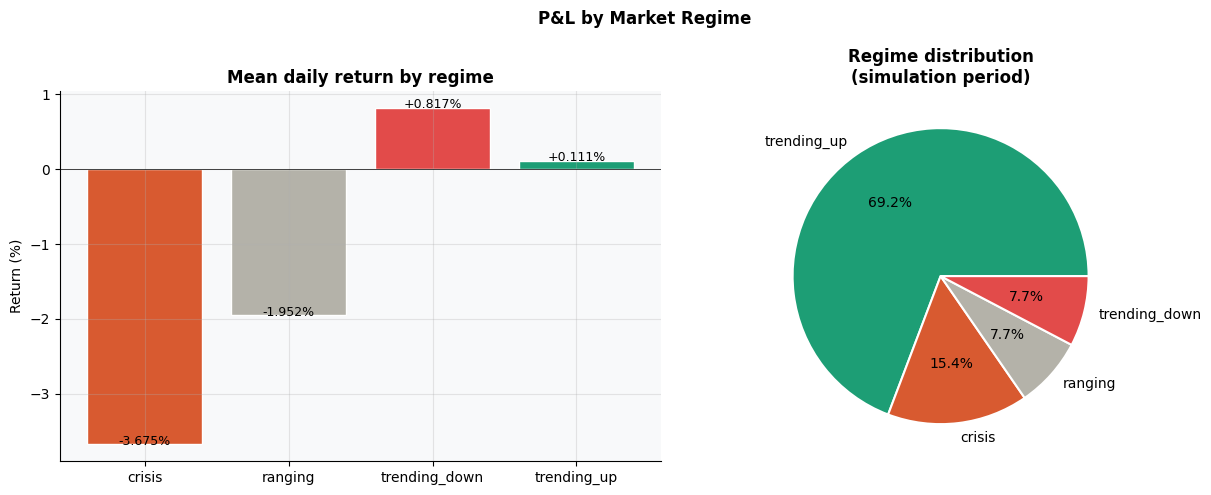

In [6]:
if not sim_df.empty and 'regime' in sim_df.columns and 'portfolio_value' in sim_df.columns:
    sim_df['daily_return'] = sim_df['portfolio_value'].pct_change().fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Mean daily return per regime
    ret_by_regime = sim_df.groupby('regime')['daily_return'].agg(['mean','std','count'])
    ret_by_regime['mean_%'] = ret_by_regime['mean'] * 100

    colours = [RCOLOURS.get(r,'#888') for r in ret_by_regime.index]
    bars = axes[0].bar(ret_by_regime.index, ret_by_regime['mean_%'],
                        color=colours, edgecolor='white')
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].set_title('Mean daily return by regime', fontweight='bold')
    axes[0].set_ylabel('Return (%)')
    for bar, v in zip(bars, ret_by_regime['mean_%']):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                      bar.get_height()+(0.002 if v>=0 else -0.005),
                      f'{v:+.3f}%', ha='center', fontsize=9)

    # Days in each regime
    counts = sim_df['regime'].value_counts()
    axes[1].pie(counts.values,
                labels=counts.index,
                colors=[RCOLOURS.get(r,'#888') for r in counts.index],
                autopct='%1.1f%%',
                wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[1].set_title('Regime distribution\n(simulation period)', fontweight='bold')

    plt.suptitle('P&L by Market Regime', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p5_02_regime_pnl.png', dpi=130, bbox_inches='tight')
    plt.show()

## 4 — Trade log analysis

In [7]:
trade_path = Path(MODEL_DIR) / 'trade_log.csv'
trade_df   = pd.read_csv(trade_path) if trade_path.exists() else pd.DataFrame()

if not trade_df.empty:
    print(f'Total trades : {len(trade_df):,}')
    if 'symbol' in trade_df.columns:
        print(f'Per asset:\n{trade_df["symbol"].value_counts().to_string()}')
    if 'direction' in trade_df.columns:
        print(f'\nPer direction:\n{trade_df["direction"].value_counts().to_string()}')
    print(f'\nSample trades:')
    cols = [c for c in ['timestamp','symbol','direction','quantity','price','trade_value']
            if c in trade_df.columns]
    print(trade_df[cols].tail(5).to_string(index=False))
else:
    print('No trade log yet — run Phase 5 simulation first')

Total trades : 55
Per asset:
symbol
BTC-USD     12
ETH-USD     12
GC=F        12
EURUSD=X    10
KES=X        9

Per direction:
direction
SHORT    28
LONG     22
CLOSE     5

Sample trades:
                 timestamp   symbol direction    quantity      price  trade_value
2026-05-21T09:05:14.563889     GC=F      LONG    0.031643  2026.6000        64.13
2026-05-21T09:05:14.754746 EURUSD=X     CLOSE -191.587890     1.0952       209.82
2026-05-21T09:05:14.764032  BTC-USD     SHORT    0.006375 46139.7305       294.16
2026-05-21T09:05:14.785263  ETH-USD     SHORT   -2.724150  2344.8271      6387.66
2026-05-21T09:05:14.804839     GC=F      LONG   -0.489615  2026.4000       992.16


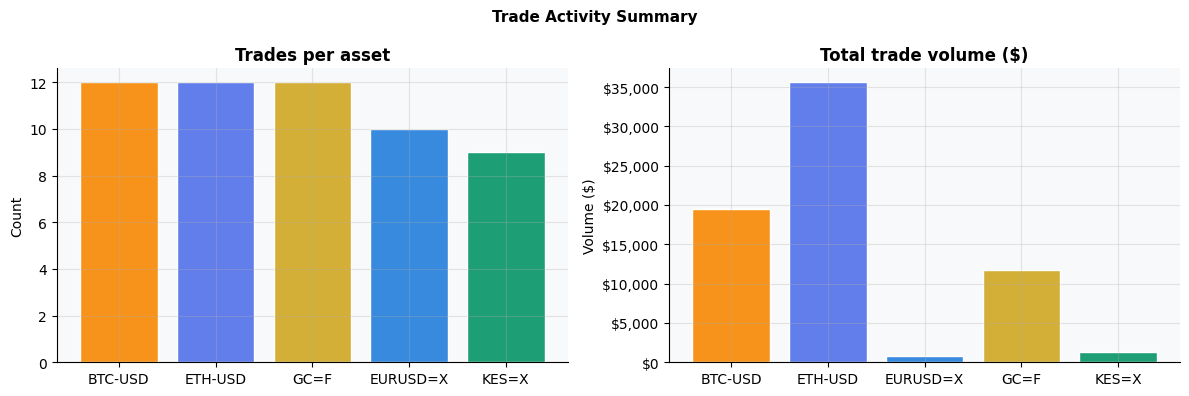

In [8]:
if not trade_df.empty and 'symbol' in trade_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ASSET_COLS = {
        'EURUSD=X':'#378ADD','KES=X':'#1D9E75',
        'BTC-USD':'#F7931A','ETH-USD':'#627EEA','GC=F':'#D4AF37'
    }

    counts  = trade_df['symbol'].value_counts()
    colours = [ASSET_COLS.get(s,'#888') for s in counts.index]
    axes[0].bar(counts.index, counts.values, color=colours, edgecolor='white')
    axes[0].set_title('Trades per asset', fontweight='bold')
    axes[0].set_ylabel('Count')

    if 'trade_value' in trade_df.columns:
        vol_by_sym = trade_df.groupby('symbol')['trade_value'].sum()
        axes[1].bar(vol_by_sym.index, vol_by_sym.values,
                     color=[ASSET_COLS.get(s,'#888') for s in vol_by_sym.index],
                     edgecolor='white')
        axes[1].set_title('Total trade volume ($)', fontweight='bold')
        axes[1].set_ylabel('Volume ($)')
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    plt.suptitle('Trade Activity Summary', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p5_03_trade_activity.png', dpi=130, bbox_inches='tight')
    plt.show()

## 5 — Risk metrics summary

In [9]:
if not sim_df.empty and 'portfolio_value' in sim_df.columns:
    pv   = sim_df['portfolio_value'].values
    rets = np.diff(np.log(pv + 1e-8))

    total_ret = (pv[-1] / pv[0] - 1) * 100
    sharpe    = _sharpe(rets)
    sortino   = _sortino(rets)
    max_dd    = _max_drawdown(pv) * 100
    win_rate  = (rets > 0).mean() * 100
    n_trades  = len(trade_df) if not trade_df.empty else 0

    print('CARMS Paper Trading — Risk Metrics Summary')
    print('='*50)
    print(f'  Total return    : {total_ret:+.2f}%')
    print(f'  Sharpe ratio    : {sharpe:.3f}')
    print(f'  Sortino ratio   : {sortino:.3f}')
    print(f'  Max drawdown    : {max_dd:.2f}%')
    print(f'  Win rate (days) : {win_rate:.1f}%')
    print(f'  Total trades    : {n_trades}')
    print(f'  Simulation days : {len(sim_df)}')
    print()

    if sharpe > 1.0 and max_dd < 15:
        print('  Status: STRONG — consider live paper trading')
    elif sharpe > 0:
        print('  Status: MODERATE — continue paper trading')
    else:
        print('  Status: NEEDS IMPROVEMENT — review Phase 4 agents')

CARMS Paper Trading — Risk Metrics Summary
  Total return    : -7.48%
  Sharpe ratio    : -4.917
  Sortino ratio   : -14.129
  Max drawdown    : 10.61%
  Win rate (days) : 58.3%
  Total trades    : 55
  Simulation days : 13

  Status: NEEDS IMPROVEMENT — review Phase 4 agents


## 6 — Comparison vs buy-and-hold

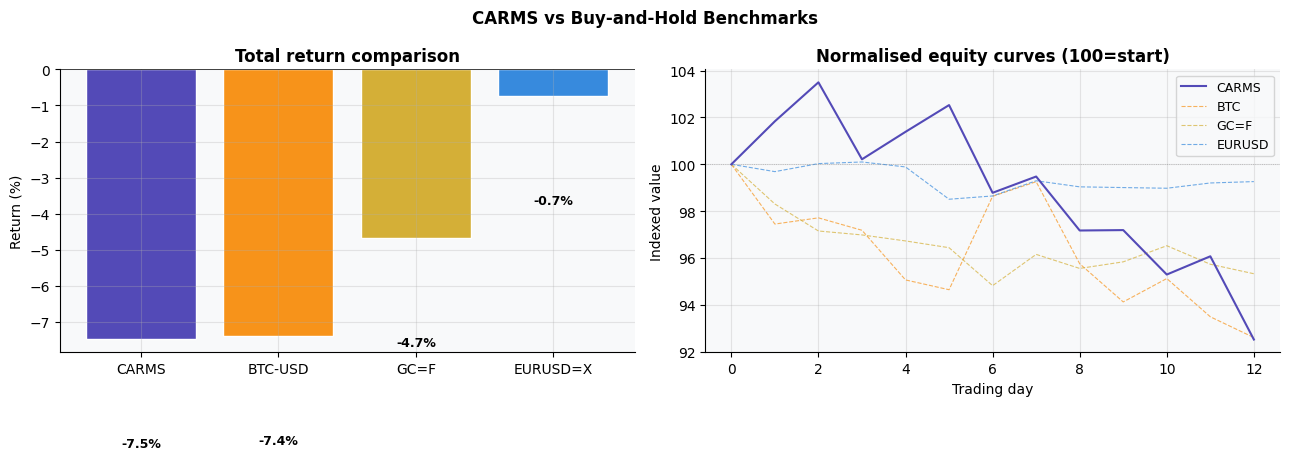


Sharpe comparison:
  CARMS    : -4.917
  BTC-USD       : -5.221
  GC=F          : -7.203
  EURUSD=X      : -2.055


In [10]:
from src.features.indicators import load_features

if not sim_df.empty and 'portfolio_value' in sim_df.columns:
    n_days = len(sim_df)
    benchmarks = {}

    for symbol in ['BTC-USD','GC=F','EURUSD=X']:
        feat = load_features(symbol)
        if feat is not None and len(feat) >= n_days:
            bh_prices = feat['close'].values[-n_days:]
            bh_ret    = (bh_prices[-1] / bh_prices[0] - 1) * 100
            bh_rets   = np.diff(np.log(bh_prices + 1e-8))
            benchmarks[symbol] = {
                'return_%': round(bh_ret, 2),
                'sharpe':   round(_sharpe(bh_rets), 3),
                'prices':   bh_prices,
            }

    pv       = sim_df['portfolio_value'].values
    carms_ret = (pv[-1] / pv[0] - 1) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Return comparison bar
    names   = ['CARMS'] + list(benchmarks.keys())
    returns = [carms_ret] + [b['return_%'] for b in benchmarks.values()]
    colours = ['#534AB7','#F7931A','#D4AF37','#378ADD']
    bars    = axes[0].bar(names, returns, color=colours[:len(names)], edgecolor='white')
    axes[0].axhline(0, color='black', linewidth=0.5)
    axes[0].set_title('Total return comparison', fontweight='bold')
    axes[0].set_ylabel('Return (%)')
    for bar, v in zip(bars, returns):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                      bar.get_height()+(1 if v>=0 else -3),
                      f'{v:+.1f}%', ha='center', fontsize=9, fontweight='bold')

    # Normalised equity curves
    axes[1].plot(pv/pv[0]*100, color='#534AB7', linewidth=1.5,
                  label='CARMS', zorder=5)
    bm_cols = ['#F7931A','#D4AF37','#378ADD']
    for (sym, bm), col in zip(benchmarks.items(), bm_cols):
        p = bm['prices']
        axes[1].plot(p/p[0]*100, color=col, linewidth=0.8,
                      linestyle='--', alpha=0.7,
                      label=sym.replace('=X','').replace('-USD',''))
    axes[1].axhline(100, color='gray', linestyle=':', linewidth=0.6, alpha=0.5)
    axes[1].set_title('Normalised equity curves (100=start)', fontweight='bold')
    axes[1].set_ylabel('Indexed value')
    axes[1].set_xlabel('Trading day')
    axes[1].legend(fontsize=9)

    plt.suptitle('CARMS vs Buy-and-Hold Benchmarks', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('logs/p5_04_vs_benchmarks.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\nSharpe comparison:')
    carms_rets = np.diff(np.log(pv + 1e-8))
    print(f'  CARMS    : {_sharpe(carms_rets):.3f}')
    for sym, bm in benchmarks.items():
        print(f'  {sym:<14}: {bm["sharpe"]:.3f}')

## ✅ Phase 5 complete

**Next steps:**

```bash
# Start live paper trading (real prices, zero real money)
python main.py --phase 5 --live

# Launch real-time dashboard
python main.py --phase 5 --dashboard
# Open: http://localhost:8050
```

**Paper trading checklist before going live:**
- [ ] Sharpe > 1.0 over 252-day simulation
- [ ] Max drawdown < 15%
- [ ] At least 4 weeks live paper trading
- [ ] No circuit breakers triggered
- [ ] Review all trade logs